In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR, LinearSVR
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

from bitcoin_forecasting.data_prep.raw_data import read_raw_bitcoin_data
from bitcoin_forecasting.data_prep.pipeline import run_data_pipeline
from bitcoin_forecasting.data_prep.constants import RawBitcoinColumn, RAW_BITCOIN_DATA_PATH
from bitcoin_forecasting.feature import autoregressive_features
from bitcoin_forecasting.eval.eval import evaluate, evaluate_predictions
from bitcoin_forecasting.feature.custom_features import add_log_ret_features
from bitcoin_forecasting.feature import engineer_features
from bitcoin_forecasting.config.feature_config import FeatureConfig 
from bitcoin_forecasting.data_prep.data_resample import resample_dataframe_with_aggregations


✓ Function 'resample_dataframe_with_aggregations' defined


In [2]:
from bitcoin_forecasting.data_prep.data_merge import merge_all_raw_data
from bitcoin_forecasting.data_prep.pipeline import run_data_pipeline
from bitcoin_forecasting.data_prep.raw_data import read_raw_bitcoin_data, read_raw_eth_data, read_raw_gold_data, read_raw_sp500_data
from bitcoin_forecasting.data_prep.constants import RawBitcoinColumn, RawEthColumn, RawGoldPriceColumn, RawSP500Column 

In [3]:
btc_df_cleaned = run_data_pipeline(read_raw_bitcoin_data, timestamp_column=RawBitcoinColumn.OPEN_TIME)
eth_df_cleaned = run_data_pipeline(read_raw_eth_data, timestamp_column=RawEthColumn.OPEN_TIME)
gold_df_cleaned = run_data_pipeline(read_raw_gold_data, timestamp_column=RawGoldPriceColumn.OPEN_TIME)
sp500_df_cleaned = run_data_pipeline(read_raw_sp500_data, timestamp_column=RawSP500Column.OPEN_TIME)


Duplikat-Check
✓ Keine doppelten Zeitstempel im Index
✓ Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
⚠ Es gibt 27 Lücken in der stündlichen Zeitreihe.

NaN-Check
✓ Keine NaN-Werte gefunden!

0-Werte Check
⚠ 15 0-Werte insgesamt gefunden:
  Volume: 3 (0.00%)
  Quote asset volume: 3 (0.00%)
  Number of trades: 3 (0.00%)
  Taker buy base asset volume: 3 (0.00%)
  Taker buy quote asset volume: 3 (0.00%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 70,174 Einträge
  Aktueller DataFrame:    70,052 Zeilen
  Zu ergänzende Einträge: 122
    Volume: 3 Nullwerte → NaN ersetzt
    Quote asset volume: 3 Nullwerte → NaN ersetzt
    Number of trades: 3 Nullwerte → NaN ersetzt
    Taker buy base asset volume: 3 Nullwerte → NaN ersetzt
    Taker buy quote asset volume: 3 Nullwerte → NaN ersetzt

  Interpoliere 9 numerische Spalten:
    Open: 122 → 0 NaN
    High: 122 → 0 NaN
    Low: 122 → 0 NaN
    Close: 122 → 0 NaN
    Volume: 125 

In [4]:
sp500_df_cleaned

,Open,High,Low,Close,Volume,Mode
2018-01-02 05:00:00,2683.729980,2695.889893,2682.360107,2695.810059,3.397430e+09,Train
2018-01-02 06:00:00,2684.318319,2696.659902,2683.002187,2696.528809,3.403538e+09,Train
2018-01-02 07:00:00,2684.906657,2697.429911,2683.644267,2697.247559,3.409647e+09,Train
2018-01-02 08:00:00,2685.494995,2698.199921,2684.286346,2697.966309,3.415755e+09,Train
2018-01-02 09:00:00,2686.083333,2698.969930,2684.928426,2698.685059,3.421863e+09,Train
...,...,...,...,...,...,...
2025-12-31 01:00:00,6899.089844,6903.391602,6852.703206,6853.956706,3.269847e+09,Test
2025-12-31 02:00:00,6899.022339,6902.898682,6850.664856,6851.842529,3.267842e+09,Test
2025-12-31 03:00:00,6898.954834,6902.405762,6848.626506,6849.728353,3.265838e+09,Test
2025-12-31 04:00:00,6898.887329,6901.912842,6846.588155,6847.614176,3.263834e+09,Test


In [5]:
merged_df = merge_all_raw_data(btc_df_cleaned, eth_df_cleaned, gold_df_cleaned, sp500_df_cleaned)

In [6]:
df = merged_df.copy()
df

,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,BTC_Quote asset volume,BTC_Number of trades,BTC_Taker buy base asset volume,BTC_Taker buy quote asset volume,BTC_Mode,...,GOLD_Low,GOLD_Close,GOLD_Volume,GOLD_Mode,SP500_Open,SP500_High,SP500_Low,SP500_Close,SP500_Volume,SP500_Mode
2018-01-02 09:00:00,13342.97,13523.46,13326.10,13452.00,511.542770,6.875573e+06,4383.0,296.566815,3.988158e+06,Train,...,1308.62,1309.28,6186.0,Train,2686.083333,2698.969930,2684.928426,2698.685059,3.421863e+09,Train
2018-01-02 10:00:00,13460.00,13617.28,13401.60,13560.00,654.454591,8.861014e+06,5114.0,393.745927,5.332073e+06,Train,...,1308.40,1310.12,7032.0,Train,2686.671672,2699.739939,2685.570506,2699.403809,3.427972e+09,Train
2018-01-02 11:00:00,13566.50,13573.00,13401.05,13490.00,684.541650,9.232321e+06,4638.0,409.158616,5.518230e+06,Train,...,1309.88,1312.14,6350.0,Train,2687.260010,2700.509949,2686.212585,2700.122559,3.434080e+09,Train
2018-01-02 12:00:00,13490.00,13590.00,13450.46,13489.04,671.205943,9.081599e+06,5411.0,444.767026,6.018779e+06,Train,...,1310.03,1311.74,7029.0,Train,2687.848348,2701.279958,2686.854665,2700.841309,3.440188e+09,Train
2018-01-02 13:00:00,13489.04,13875.00,13470.41,13864.98,1036.836330,1.420579e+07,9538.0,622.888065,8.534969e+06,Train,...,1310.04,1310.06,4391.0,Train,2688.436686,2702.049967,2687.496745,2701.560059,3.446297e+09,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 01:00:00,88255.54,88784.00,88172.15,88649.33,355.757400,3.150483e+07,121981.0,234.190280,2.073944e+07,Test,...,4327.85,4338.94,26581.0,Test,6899.089844,6903.391602,6852.703206,6853.956706,3.269847e+09,Test
2025-12-31 02:00:00,88649.32,88742.00,88521.84,88673.60,258.233980,2.289035e+07,96189.0,112.996740,1.001594e+07,Test,...,4332.27,4342.27,42795.0,Test,6899.022339,6902.898682,6850.664856,6851.842529,3.267842e+09,Test
2025-12-31 03:00:00,88673.61,88819.80,88379.09,88453.04,274.041840,2.427102e+07,87109.0,117.645550,1.042073e+07,Test,...,4336.72,4366.15,96426.0,Test,6898.954834,6902.405762,6848.626506,6849.728353,3.265838e+09,Test
2025-12-31 04:00:00,88453.04,88549.50,88325.06,88325.06,158.174840,1.398649e+07,57895.0,56.284240,4.977181e+06,Test,...,4346.68,4348.77,76230.0,Test,6898.887329,6901.912842,6846.588155,6847.614176,3.263834e+09,Test


In [7]:
df.columns

Index(['BTC_Open', 'BTC_High', 'BTC_Low', 'BTC_Close', 'BTC_Volume',
       'BTC_Quote asset volume', 'BTC_Number of trades',
       'BTC_Taker buy base asset volume', 'BTC_Taker buy quote asset volume',
       'BTC_Mode', 'ETH_Open', 'ETH_High', 'ETH_Low', 'ETH_Close',
       'ETH_Volume', 'ETH_Mode', 'GOLD_Open', 'GOLD_High', 'GOLD_Low',
       'GOLD_Close', 'GOLD_Volume', 'GOLD_Mode', 'SP500_Open', 'SP500_High',
       'SP500_Low', 'SP500_Close', 'SP500_Volume', 'SP500_Mode'],
      dtype='object')

In [8]:
# Test the function
frequency_resample = '1h'

resampled = resample_dataframe_with_aggregations(df, frequency_resample)
print(f"Original shape: {df.shape}")
print(f"Resampled {frequency_resample} shape: {resampled.shape}")
print(f"\nFirst few rows of resampled data:")
print(resampled.head())

Original shape: (70077, 28)
Resampled 1h shape: (70077, 28)

First few rows of resampled data:
                     BTC_Open  BTC_High   BTC_Low  BTC_Close   BTC_Volume  \
2018-01-02 09:00:00  13342.97  13523.46  13326.10   13452.00   511.542770   
2018-01-02 10:00:00  13460.00  13617.28  13401.60   13560.00   654.454591   
2018-01-02 11:00:00  13566.50  13573.00  13401.05   13490.00   684.541650   
2018-01-02 12:00:00  13490.00  13590.00  13450.46   13489.04   671.205943   
2018-01-02 13:00:00  13489.04  13875.00  13470.41   13864.98  1036.836330   

                     BTC_Quote asset volume  BTC_Number of trades  \
2018-01-02 09:00:00            6.875573e+06                4383.0   
2018-01-02 10:00:00            8.861014e+06                5114.0   
2018-01-02 11:00:00            9.232321e+06                4638.0   
2018-01-02 12:00:00            9.081599e+06                5411.0   
2018-01-02 13:00:00            1.420579e+07                9538.0   

                     BTC_Ta

In [9]:
df = resampled.copy()

In [10]:
models = [
    # RandomForestRegressor(random_state=42),
    # DecisionTreeRegressor(random_state=42),
    SVR(),
    LinearSVR(random_state=42),
    LGBMRegressor(random_state=42),
    XGBRegressor(random_state=42),
    LinearRegression(),
    KNeighborsRegressor()
]

In [11]:
df["type"] = "BTC"
df["timestamp"] = df.index

In [12]:
feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "BTC_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [13]:
feature_df.columns

Index(['BTC_Open', 'BTC_High', 'BTC_Low', 'BTC_Close', 'BTC_Volume',
       'BTC_Quote asset volume', 'BTC_Number of trades',
       'BTC_Taker buy base asset volume', 'BTC_Taker buy quote asset volume',
       'BTC_Mode', 'ETH_Open', 'ETH_High', 'ETH_Low', 'ETH_Close',
       'ETH_Volume', 'ETH_Mode', 'GOLD_Open', 'GOLD_High', 'GOLD_Low',
       'GOLD_Close', 'GOLD_Volume', 'GOLD_Mode', 'SP500_Open', 'SP500_High',
       'SP500_Low', 'SP500_Close', 'SP500_Volume', 'SP500_Mode', 'type',
       'timestamp', 'BTC_Close_log_ret'],
      dtype='object')

In [14]:
numeric_feature_columns = ['BTC_Open', 'BTC_High', 'BTC_Low', 'BTC_Close', 'BTC_Volume',
       'BTC_Quote asset volume', 'BTC_Number of trades',
       'BTC_Taker buy base asset volume', 'BTC_Taker buy quote asset volume',
       'ETH_Open', 'ETH_High', 'ETH_Low', 'ETH_Close',
       'ETH_Volume', 'GOLD_Open', 'GOLD_High', 'GOLD_Low',
       'GOLD_Close', 'GOLD_Volume', 'SP500_Open', 'SP500_High',
       'SP500_Low', 'SP500_Close', 'SP500_Volume', 'BTC_Close_log_ret'
       #,'ETH_Close_log_ret'
       ]

# Feature Engineering

### Lag Features

In [15]:
lag_window_len = 12

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [16]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [17]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [18]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [19]:
def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="BTC_Close_log_ret",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

In [20]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

In [21]:
df_train = features_df[features_df["BTC_Mode"] == "Train"].dropna()
df_val = features_df[features_df["BTC_Mode"] == "Val"]
df_test = features_df[features_df["BTC_Mode"] == "Test"]

In [22]:
train_features, train_target, _ = feature_config.get_X_y(df_train)
val_features, val_target, _ = feature_config.get_X_y(df_val)
test_features, test_target, _ = feature_config.get_X_y(df_test)

In [23]:
def trainmodel(model, train_features, train_target, val_features, val_target, test_features, test_target):
    model.fit(train_features, train_target)
    val_preds = model.predict(val_features)
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    test_preds = model.predict(test_features)
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    return val_score, test_score

In [24]:
# Define baseline models
def naive_baseline(train_target, val_target, test_target):
    """
    Naive baseline: Use last training value as prediction for all test samples
    """
    last_train_value = train_target.values[-1][0] if len(train_target.shape) > 1 else train_target.values[-1]
    
    val_preds = np.full(len(val_target), last_train_value)
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    test_preds = np.full(len(test_target), last_train_value)
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    return val_score, test_score


def mean_baseline(train_target, val_target, test_target):
    """
    Mean baseline: Use mean of training values as prediction for all test samples
    """
    mean_train_value = train_target.values.mean()
    
    val_preds = np.full(len(val_target), mean_train_value)
    val_eval_df = val_target.copy()
    val_eval_df["pred"] = val_preds
    val_score = evaluate(val_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    test_preds = np.full(len(test_target), mean_train_value)
    test_eval_df = test_target.copy()
    test_eval_df["pred"] = test_preds
    test_score = evaluate(test_eval_df, target_col="BTC_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
    
    return val_score, test_score

print("✓ Baseline functions defined")

✓ Baseline functions defined


In [25]:
results = []

# Naive Baseline
print("Training Naive Baseline...")
val_score, test_score = naive_baseline(train_target, val_target, test_target)
print(f"Naive Baseline - Test Score: {test_score}")
results.append({
    "Model": "Naive (Lag-1)",
    "MAE": test_score.mae,
    "RMSE": test_score.rmse,
    "MSE": test_score.mse,
    "R2": test_score.r2,
    "SMAPE": test_score.smape,
    "SMAPE_Total": test_score.smape_total,
    "Forecast_Bias": test_score.forecast_bias,
    "Accuracy_Total": test_score.accuracy_total,
    "Directed_Accuracy": test_score.directed_accuracy
})

# Mean Baseline
print("\nTraining Mean Baseline...")
val_score, test_score = mean_baseline(train_target, val_target, test_target)
print(f"Mean Baseline - Test Score: {test_score}")
results.append({
    "Model": "Mean Baseline",
    "MAE": test_score.mae,
    "RMSE": test_score.rmse,
    "MSE": test_score.mse,
    "R2": test_score.r2,
    "SMAPE": test_score.smape,
    "SMAPE_Total": test_score.smape_total,
    "Forecast_Bias": test_score.forecast_bias,
    "Accuracy_Total": test_score.accuracy_total,
    "Directed_Accuracy": test_score.directed_accuracy
})

# ML Models
print("\nTraining ML Models...")
for model in models:
    val_score, test_score = trainmodel(model, train_features, train_target, val_features, val_target, test_features, test_target)
    model_name = model.__class__.__name__
    print(f"{model_name} - Test Score: {test_score}") 
    
    results.append({
        "Model": model_name,
        "MAE": test_score.mae,
        "RMSE": test_score.rmse,
        "MSE": test_score.mse,
        "R2": test_score.r2,
        "SMAPE": test_score.smape,
        "SMAPE_Total": test_score.smape_total,
        "Forecast_Bias": test_score.forecast_bias,
        "Accuracy_Total": test_score.accuracy_total,
        "Directed_Accuracy": test_score.directed_accuracy
    })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print(results_df.to_string())
print("="*80)

Training Naive Baseline...
Naive Baseline - Test Score: EvaluationResults(mae=0.003685167789736164, rmse=0.005329940704330278, mse=2.8408267911676743e-05, r2=-0.15100193368992487, smape=-2.010039440854262, smape_total=-1.0529867780249509, forecast_bias=-0.001930525779009808, accuracy=301.00394408542616, accuracy_total=205.2986778024951, directed_accuracy=0.4912952328867013)

Training Mean Baseline...
Mean Baseline - Test Score: EvaluationResults(mae=0.00317669960574433, rmse=0.004968056886122773, mse=2.4681589223751896e-05, r2=-1.017349607512763e-05, smape=39.07430039566387, smape_total=0.19491018049537961, forecast_bias=-1.5845993076409376e-05, accuracy=-3807.4300395663868, accuracy_total=80.50898195046204, directed_accuracy=0.5086591924163705)

Training ML Models...


c:\Users\phili\anaconda3\envs\btc_forecast\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR - Test Score: EvaluationResults(mae=0.008815479489830814, rmse=0.0107621892607693, mse=0.00011582471768461805, r2=-3.692805433916946, smape=1.1480206591618731, smape_total=0.9873490259884266, forecast_bias=0.007581705972312239, accuracy=-14.802065916187317, accuracy_total=1.2650974011573481, directed_accuracy=0.5085680430225139)


c:\Users\phili\anaconda3\envs\btc_forecast\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\phili\anaconda3\envs\btc_forecast\lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVR - Test Score: EvaluationResults(mae=0.0031771021205409837, rmse=0.00496826905604566, mse=2.4683697413260833e-05, r2=-9.558983363278095e-05, smape=65.40952127977215, smape_total=0.9999999999061717, forecast_bias=-4.857247168426224e-05, accuracy=-6440.952127977215, accuracy_total=9.382830512549845e-09, directed_accuracy=4.5574696928265424e-05)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 153000
[LightGBM] [Info] Number of data points in the train set: 35018, number of used features: 600
[LightGBM] [Info] Start training from score 0.000033
LGBMRegressor - Test Score: EvaluationResults(mae=0.003328930808727014, rmse=0.005157515557915193, mse=2.6599966730137267e-05, r2=-0.07773600409799064, smape=-18.908544122782622, smape_total=-1.5517896146293166, forecast_

EvaluationResults(mae=0.004706323237074112, rmse=0.007087773214387119, mse=5.0236529138583506e-05, r2=-1.0396789200225482, smape=np.float64(47.8661401103568), smape_total=np.float64(0.0017458557725687997), forecast_bias=np.float64(-1.716570747521524e-07), accuracy=np.float64(-4686.61401103568), accuracy_total=np.float64(99.82541442274312), directed_accuracy=np.float64(0.47323457238934835))

EvaluationResults(mae=0.0031731496469194166, rmse=0.004962844749638309, mse=2.462982800901253e-05, r2=-8.198320770702594e-06, smape=np.float64(37.64815042878884), smape_total=np.float64(0.16859490802101182), forecast_bias=np.float64(-1.4209911158084186e-05), accuracy=np.float64(-3664.815042878884), accuracy_total=np.float64(83.14050919789882), directed_accuracy=np.float64(0.5086340089066618))

In [ ]:
# Save Results
import os
from pathlib import Path

results_dir = Path("../results/sklearn_baselines")
results_dir.mkdir(parents=True, exist_ok=True)

csv_path = results_dir / "baseline_comparison_one_step_res_1h_no_eth.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

Results saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.csv


In [468]:
# Plot Results with Baselines
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Comparison - Test Set Performance (with Baselines)", fontsize=16, fontweight='bold')

# MAE
ax = axes[0, 0]
results_df_sorted = results_df.sort_values("MAE")
ax.barh(results_df_sorted["Model"], results_df_sorted["MAE"], color='steelblue')
ax.set_xlabel("MAE (Mean Absolute Error)")
ax.set_title("MAE - Lower is Better")
ax.invert_yaxis()

# RMSE
ax = axes[0, 1]
results_df_sorted = results_df.sort_values("RMSE")
ax.barh(results_df_sorted["Model"], results_df_sorted["RMSE"], color='coral')
ax.set_xlabel("RMSE (Root Mean Squared Error)")
ax.set_title("RMSE - Lower is Better")
ax.invert_yaxis()

# R²
ax = axes[0, 2]
results_df_sorted = results_df.sort_values("R2", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["R2"], color='lightgreen')
ax.set_xlabel("R² Score")
ax.set_title("R² - Higher is Better")
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)

# Directed Accuracy
ax = axes[1, 0]
results_df_sorted = results_df.sort_values("Directed_Accuracy", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["Directed_Accuracy"] * 100, color='mediumpurple')
ax.set_xlabel("Accuracy (%)")
ax.set_title("Directional Accuracy - Higher is Better")
ax.invert_yaxis()

# Forecast Bias
ax = axes[1, 1]
results_df_sorted = results_df.sort_values("Forecast_Bias")
colors = ['red' if x < 0 else 'green' for x in results_df_sorted["Forecast_Bias"]]
ax.barh(results_df_sorted["Model"], results_df_sorted["Forecast_Bias"], color=colors)
ax.set_xlabel("Forecast Bias")
ax.set_title("Forecast Bias - Closer to 0 is Better")
ax.invert_yaxis()
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Accuracy Total
ax = axes[1, 2]
results_df_sorted = results_df.sort_values("Accuracy_Total", ascending=False)
ax.barh(results_df_sorted["Model"], results_df_sorted["Accuracy_Total"], color='gold')
ax.set_xlabel("Accuracy Total (%)")
ax.set_title("Accuracy Total - Higher is Better")
ax.invert_yaxis()

plt.tight_layout()
fig_path = results_dir / "baseline_comparison_one_step_res_1h.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {fig_path}")
plt.show()

# Save updated results
csv_path = results_dir / "baseline_comparison_one_step_res_1h.csv"
results_df.to_csv(csv_path, index=False)
print(f"Updated results saved to: {csv_path}")

Results saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.csv


Plot saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.png


Plot saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.png


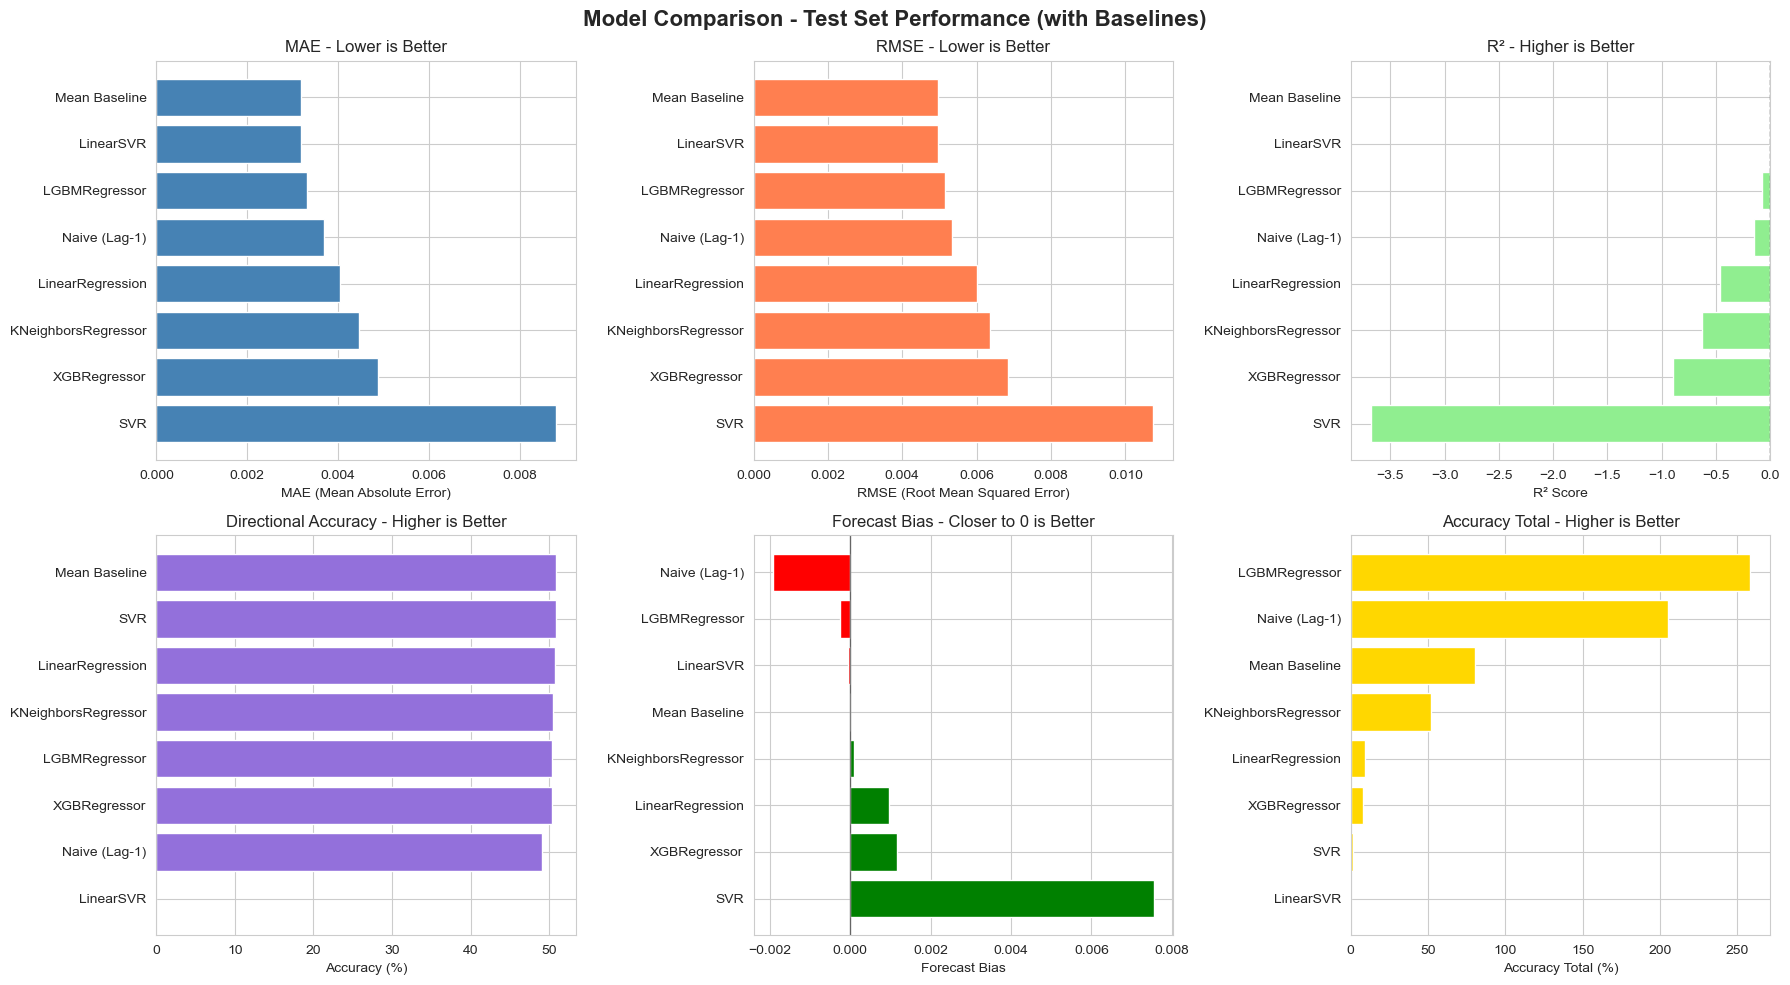

Updated results saved to: ..\results\sklearn_baselines\baseline_comparison_one_step_res_1h.csv


In [473]:
# Train LGBM models für Feature Importance
rf_model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(train_features, train_target)

LGBM_importance = pd.DataFrame({
    'feature': train_features.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nLightGBM - Top 20 Features:")
print(LGBM_importance.head(40))

In [474]:
# LGBM: Predictions vs Ground Truth
import matplotlib.pyplot as plt

# Train LGBM and get predictions
lgbm_model = LGBMRegressor(random_state=42)
lgbm_model.fit(train_features, train_target)
lgbm_test_preds = lgbm_model.predict(test_features)

# Create comparison dataframe
test_comparison = pd.DataFrame({
    'Time': range(len(test_target)),
    'Ground Truth': test_target.values.flatten(),
    'LGBM Predictions': lgbm_test_preds
})

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_comparison['Time'], test_comparison['Ground Truth'], label='Ground Truth', linewidth=2, marker='o', markersize=3, alpha=0.7)
ax.plot(test_comparison['Time'], test_comparison['LGBM Predictions'], label='LGBM Predictions', linewidth=2, marker='s', markersize=3, alpha=0.7)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('BTC Close Log Return', fontsize=12)
ax.set_title('LGBM: Predictions vs Ground Truth (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 159120
[LightGBM] [Info] Number of data points in the train set: 35018, number of used features: 624
[LightGBM] [Info] Start training from score 0.000033

LightGBM - Top 20 Features:
                               feature  importance
222            BTC_Close_log_ret_lag_1          52
342            BTC_Close_log_ret_lag_4          46
309            BTC_Close_log_ret_lag_5          41
120   BTC_Close_log_ret_rolling_3_mean          40
109            ETH_Close_log_ret_lag_7          39
592           BTC_Close_log_ret_lag_12          38
397  BTC_Close_log_ret_rolling_12_mean          38
172            ETH_Close_log_ret_lag_2          37
550           BTC_Close_log_ret_lag_10          36
204   BTC_Close_log_ret_rolling_6_me

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 159120
[LightGBM] [Info] Number of data points in the train set: 35018, number of used features: 624
[LightGBM] [Info] Start training from score 0.000033


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 159120
[LightGBM] [Info] Number of data points in the train set: 35018, number of used features: 624
[LightGBM] [Info] Start training from score 0.000033


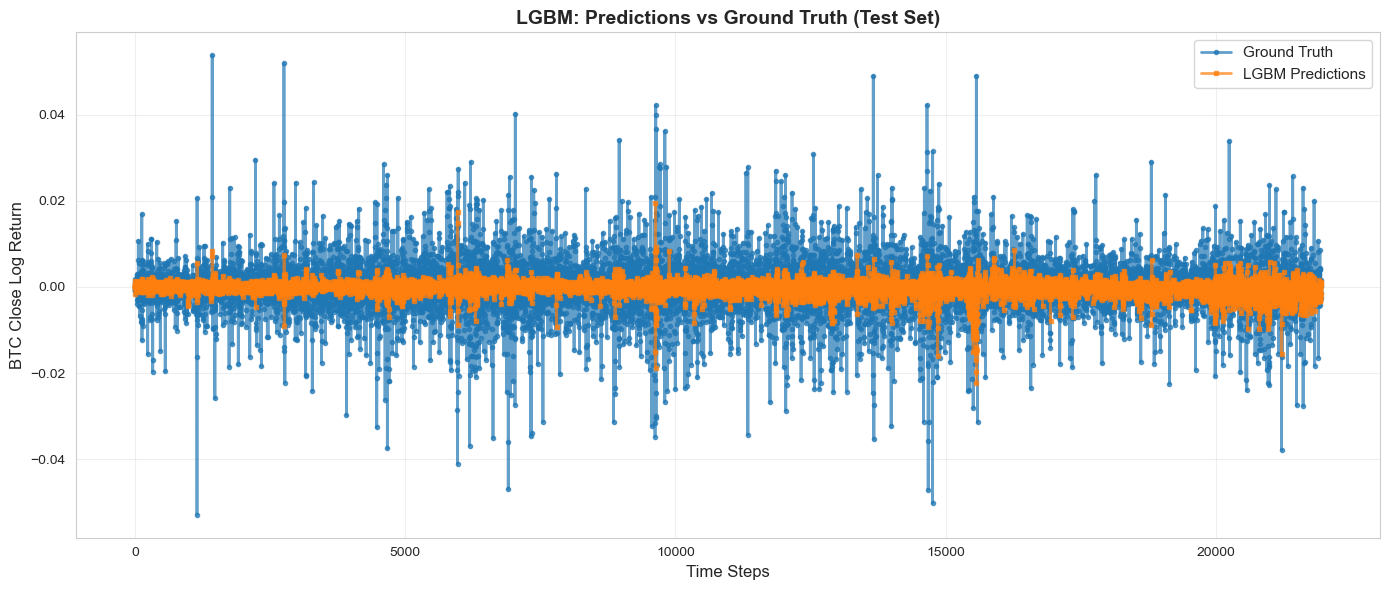

In [471]:
# LGBM: Zoomed Version - First 100 Data Points
# Create a zoomed-in view of the first 100 time steps for better visibility of individual predictions

zoom_steps = min(100, len(test_comparison))
test_comparison_zoomed = test_comparison.head(zoom_steps)

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(test_comparison_zoomed['Time'], test_comparison_zoomed['Ground Truth'], 
        label='BTC Returns', linewidth=2.5, marker='o', markersize=8, alpha=0.8, color='#1f77b4')
ax.plot(test_comparison_zoomed['Time'], test_comparison_zoomed['LGBM Predictions'], 
        label='LGBM Vorhersage', linewidth=2.5, marker='s', markersize=8, alpha=0.8, color='#ff7f0e')
ax.set_xlabel('', fontsize=13, fontweight='bold')
ax.set_ylabel('', fontsize=13, fontweight='bold')
ax.set_title(f'LGBM Vorhersage vs reale Werte (Erste {zoom_steps} Schritte)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()